In [5]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(1)

In [6]:
X = np.random.normal(0, 1, 100)
eps = np.random.normal(0, 0.5, 100)

Y = -1 + 0.5 * X + eps

print(f"Długość wektora Y: {len(Y)}")
print(f"Prawdziwe wartości: Beta0 = -1, Beta1 = 0.5")

Długość wektora Y: 100
Prawdziwe wartości: Beta0 = -1, Beta1 = 0.5


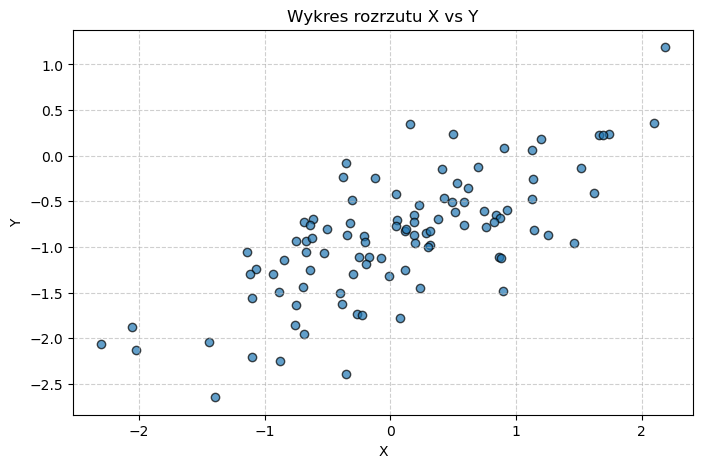

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, alpha=0.7, edgecolors='k')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Wykres rozrzutu X vs Y")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Estymowana Beta0 : -0.9265
Estymowana Beta1 : 0.5477


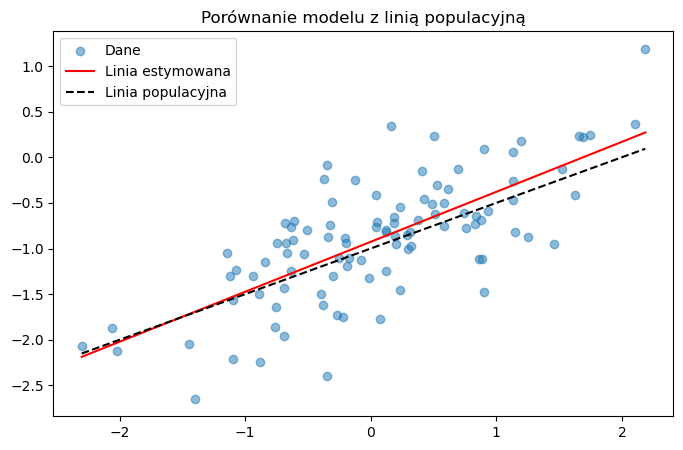

In [9]:
X_sm = sm.add_constant(X) 
model = sm.OLS(Y, X_sm).fit()

beta0_hat = model.params[0]
beta1_hat = model.params[1]

print(f"Estymowana Beta0 : {beta0_hat:.4f}")
print(f"Estymowana Beta1 : {beta1_hat:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, alpha=0.5, label='Dane')

x_line = np.linspace(X.min(), X.max(), 100)
y_est = beta0_hat + beta1_hat * x_line
plt.plot(x_line, y_est, color='red', label='Linia estymowana')

y_pop = -1 + 0.5 * x_line
plt.plot(x_line, y_pop, color='black', linestyle='--', label='Linia populacyjna')

plt.legend()
plt.title("Porównanie modelu z linią populacyjną")
plt.show()

In [10]:
X_poly = np.column_stack((X, X**2))
X_poly_sm = sm.add_constant(X_poly)

model_poly = sm.OLS(Y, X_poly_sm).fit()

print(model_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     52.96
Date:                Tue, 12 May 2026   Prob (F-statistic):           2.83e-16
Time:                        16:04:02   Log-Likelihood:                -65.107
No. Observations:                 100   AIC:                             136.2
Df Residuals:                      97   BIC:                             144.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9325      0.058    -16.158      0.0

In [12]:
def run_experiment(variance, title):
    std_dev = np.sqrt(variance)
    eps_new = np.random.normal(0, std_dev, 100)
    Y_new = -1 + 0.5 * X + eps_new 
    

    model_new = sm.OLS(Y_new, X_sm).fit()
    

    plt.figure(figsize=(8, 4))
    plt.scatter(X, Y_new, alpha=0.5, label='Dane')
    y_est_new = model_new.params[0] + model_new.params[1] * x_line
    plt.plot(x_line, y_est_new, color='red', label='Linia estymowana')
    plt.plot(x_line, y_pop, color='black', linestyle='--', label='Linia populacyjna')
    plt.title(f"{title} (Wariancja błędu = {variance})")
    plt.legend()
    plt.show()
    
    print(f"Estymaty dla {title}:")
    print(f"Beta0: {model_new.params[0]:.4f}, Beta1: {model_new.params[1]:.4f}")
    return model_new

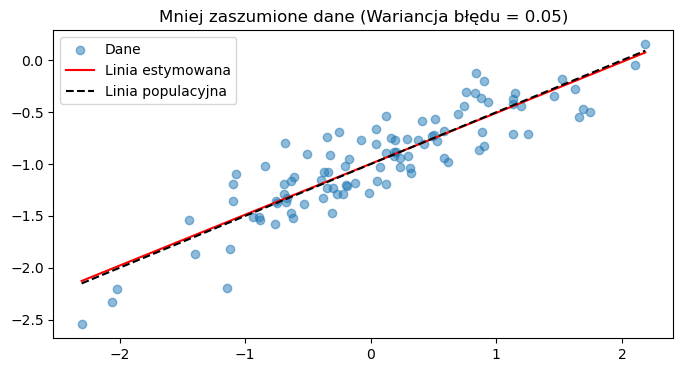

Estymaty dla Mniej zaszumione dane:
Beta0: -0.9972, Beta1: 0.4908


In [13]:
model_less_noise = run_experiment(variance=0.05, title="Mniej zaszumione dane")

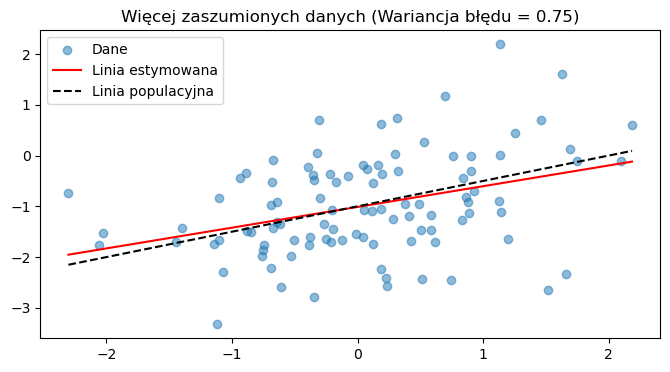

Estymaty dla Więcej zaszumionych danych:
Beta0: -1.0121, Beta1: 0.4085


In [14]:
model_more_noise = run_experiment(variance=0.75, title="Więcej zaszumionych danych")

In [15]:
import pandas as pd

ci_original = model.conf_int(alpha=0.05)
ci_less = model_less_noise.conf_int(alpha=0.05)
ci_more = model_more_noise.conf_int(alpha=0.05)

df_ci = pd.DataFrame({
    'Model': ['Oryginalny', 'Oryginalny', 'Mniej szumu', 'Mniej szumu', 'Więcej szumu', 'Więcej szumu'],
    'Parametr': ['Beta0', 'Beta1', 'Beta0', 'Beta1', 'Beta0', 'Beta1'],
    'Dolna granica (2.5%)': [ci_original[0][0], ci_original[0][1], ci_less[0][0], ci_less[0][1], ci_more[0][0], ci_more[0][1]],
    'Górna granica (97.5%)': [ci_original[1][0], ci_original[1][1], ci_less[1][0], ci_less[1][1], ci_more[1][0], ci_more[1][1]]
})

print(df_ci)

          Model Parametr  Dolna granica (2.5%)  Górna granica (97.5%)
0    Oryginalny    Beta0             -1.019741               0.442613
1    Oryginalny    Beta1             -0.833246               0.652814
2   Mniej szumu    Beta0             -1.042369               0.439962
3   Mniej szumu    Beta1             -0.952126               0.541676
4  Więcej szumu    Beta0             -1.196594               0.200547
5  Więcej szumu    Beta1             -0.827588               0.616456
